In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# **Function 1**: Searching for contamination sources

For this function we must detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading.

- The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.
- Optimisation Goal - Maximise

I want to begin this week's analysis by loading the data and appending new week's data to last week's updated data.

In [2]:
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_outputs.npy')

# New data for Week 7 (Function 1)
X_w6_new_point = np.array([0.799197, 0.803213], dtype=np.float64)
Y_w6_new_point = np.array([4.757688814579539e-42], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w6_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w6_new_point)
Y_updated = Y_all[unique_indices]

# Save the updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_1/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 1: ", X_unique)
print("Updated Outputs (Y) - Function 1: ", Y_updated)

Updated Inputs (X) - Function 1:  [[0.08250725 0.40348751]
 [0.31269116 0.07872278]
 [0.31940389 0.76295937]
 [0.41043714 0.1475543 ]
 [0.472361   0.351758  ]
 [0.57432921 0.8798981 ]
 [0.575251   0.879599  ]
 [0.65011406 0.68152635]
 [0.68341817 0.86105746]
 [0.73102363 0.73299988]
 [0.732441   0.040134  ]
 [0.799197   0.803213  ]
 [0.84035342 0.26473161]
 [0.88388983 0.58225397]
 [0.919191   0.838383  ]
 [0.996651   0.001439  ]]
Updated Outputs (Y) - Function 1:  [ 3.60677119e-081 -2.08909327e-091  1.32267704e-079 -2.15924904e-054
  2.80463460e-006  1.03307824e-046  1.46776061e-046 -3.60606264e-003
  2.53500115e-040  7.71087511e-016 -5.11184814e-169  4.75768881e-042
  3.34177101e-124  6.22985647e-048 -3.04056455e-090  0.00000000e+000]


## Output Analysis

- Last week (W5) we saw $2.80 \times 10^{-06}$, and this week (W6) we saw $4.76 \times 10^{-42}$.

- **Real-World Implication**: At first glance this looks like a step backwards — and numerically it is,4.76 \times 10^{-42} is far smaller than $2.80 \times 10^{-06}$. 

    - However this result is critically not zero. In the context of a radiation field, this tells us:
        - The contamination source's signal is detectable, however faintly, at [0.799,0.803] — the upper-right quadrant of the search space.

        - We now have two non-zero anchor points in the entire history of this function: W5 at [0.472,0.352] ($2.80 \times 10^{-06}$) and W6 at [0.799,0.803] ($4.76 \times 10^{-42}$).

        - The W5 signal is roughly $10^{36}$ times stronger than the W6 signal, which strongly suggests the source is located closer to the W5 coordinate than the W6 coordinate.

- **Model Clues**: Having two non-zero points for the first time gives the GP something genuinely meaningful to work with. 
    - The vast difference in magnitude between the two signals acts like a directional compass, it tells the model that the gradient is pointing away from [0.799,0.803] and toward [0.472,0.352]. 

        - The W7 strategy must now exploit this directionality by searching in the region surrounding the W5 anchor point, while the GP uses both data points together to estimate where the true peak lies.

### **Bayesian Optimisation**: Gaussian Process Regressor + Acquisition Function

- **Model Understanding**:
    - This week I am introducing two upgrades inspired by the top teams in the NeurIPS 2020 Black-Box Optimisation Challenge:
        - **Output power Tranformation** (from HEBO research paper): I apply a Yeo-Johnson power transformation to the outputs before fitting the GP.
            - This is essential here because our Y values span a big range.

            - Linear normalisation via `normalize_y=True` cannot handle a range this extreme; the smaller value would be numerically indistinguishable from zero and would contribute nothing to the GP's learning. 

            - The Yeo-Johnson transform compresses this into a manageable, near-normal distribution so both data points meaningfully inform the surrogate model.

        - **Multi-Kernel Search** (from Optuna research paper): I fit three GPs in parallel (Matern 2.5, Matern 1.5, and RBF) and select the query point that scores highest across all three UCB surfaces.
            - With only two non-zero points in the 2D space, we still cannot be certain about the smoothness of the radiation field.
            - The multi-kernel approach ensres we do not miss the peak due to a wrong smoothness assumption.

- The two changes are introduced because the output range from this function is so extreme that standard GP with linear normalisation would be numerically unreliable.
    - The power. transformation solves this problem, while the multi-kernel ensures the surrogate surface is as expressive as possible given such sparse data.

- To allow the GP to correctly weight, treating w5 as a stonger signal than w6.
    - This should help the w7 query to steer towards the more promising region.

In [4]:
# Output Power Transformation (HEBO)

Y_transformed = power_transform(
    Y_updated.reshape(-1,1),
    method='yeo-johnson'
).ravel()

print("Original Y:", Y_updated)
print("Transformed Y:", Y_transformed)

Original Y: [ 3.60677119e-081 -2.08909327e-091  1.32267704e-079 -2.15924904e-054
  2.80463460e-006  1.03307824e-046  1.46776061e-046 -3.60606264e-003
  2.53500115e-040  7.71087511e-016 -5.11184814e-169  4.75768881e-042
  3.34177101e-124  6.22985647e-048 -3.04056455e-090  0.00000000e+000]
Transformed Y: [ 0.25472771  0.25472771  0.25472771  0.25472771  0.30649273  0.25472771
  0.25472771 -3.87268064  0.25472771  0.25472771  0.25472771  0.25472771
  0.25472771  0.25472771  0.25472771  0.25472771]


## Acquisition Function
- I am using Upper Confidence Bound (UCB) with $\beta = 5.0$
- I am maintaining $\beta = 5.0$.
    - The signal at w5 is still orders of maginitude below what we would expect near a true maximum.
    - Lowering $\beta$ would risk premature exploitation of a region we have barely begun to characterise.
        - The multi-kernal loop runs UCB independently for each of the three kernels.
            - The query point producing the highest UCB scores across all three is selected, whichever kernel best describes the true radiation landscape around our current data will naturally win.

In [5]:
def upper_confidence_bound(X, model, beta=5.0):
    mu, sigma = model.predict(X, return_std=True)
    return mu + beta * sigma

# Generate a high-resolution grid for the 2D space
x_grid = np.array(np.meshgrid(np.linspace(0, 1, 250), np.linspace(0, 1, 250))).T.reshape(-1, 2)

# Step 2: Multi-Kernel Search (Optuna)

kernels = [
    Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + WhiteKernel(noise_level=1e-5),  
    Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=1.5) + WhiteKernel(noise_level=1e-5),  
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-5)   
]

kernel_names = ['Matern 2.5', 'Matern 1.5', 'RBF']
best_query = None
best_score = -np.inf
winning_kernel = None

for kernel, name in zip(kernels, kernel_names):
    model = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=10,
        normalize_y=False
    )
    model.fit(X_unique, Y_transformed)

    ucb_values = upper_confidence_bound(x_grid, model, beta=5.0)
    score = np.max(ucb_values)
    candidate = x_grid[np.argmax(ucb_values)]

    print(f"{name}: best UCB = {score:.6f} at [{candidate[0]:.6f}, {candidate[1]:.6f}]")

    if score > best_score:
        best_score = score
        best_query = candidate
        winning_kernel = name

next_query = best_query
print(f"\nWinning kernel: {winning_kernel}")
print(f"Strategic Week 7 Query (Function 1): [{next_query[0]:.6f}-{next_query[1]:.6f}]")

Matern 2.5: best UCB = 5.033757 at [0.835341, 0.698795]
Matern 1.5: best UCB = 5.026727 at [0.855422, 0.702811]
RBF: best UCB = 5.047335 at [0.819277, 0.694779]

Winning kernel: RBF
Strategic Week 7 Query (Function 1): [0.819277-0.694779]


/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 4/Week Function Analysis/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 4/Week Function Analysis/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/U

## **Visualisation** - GP Surrogate Surface (Winning Kernel)
- Plotting the surrogate surface from the winning kernel to visually confirm the query point makes sense.

/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 4/Week Function Analysis/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


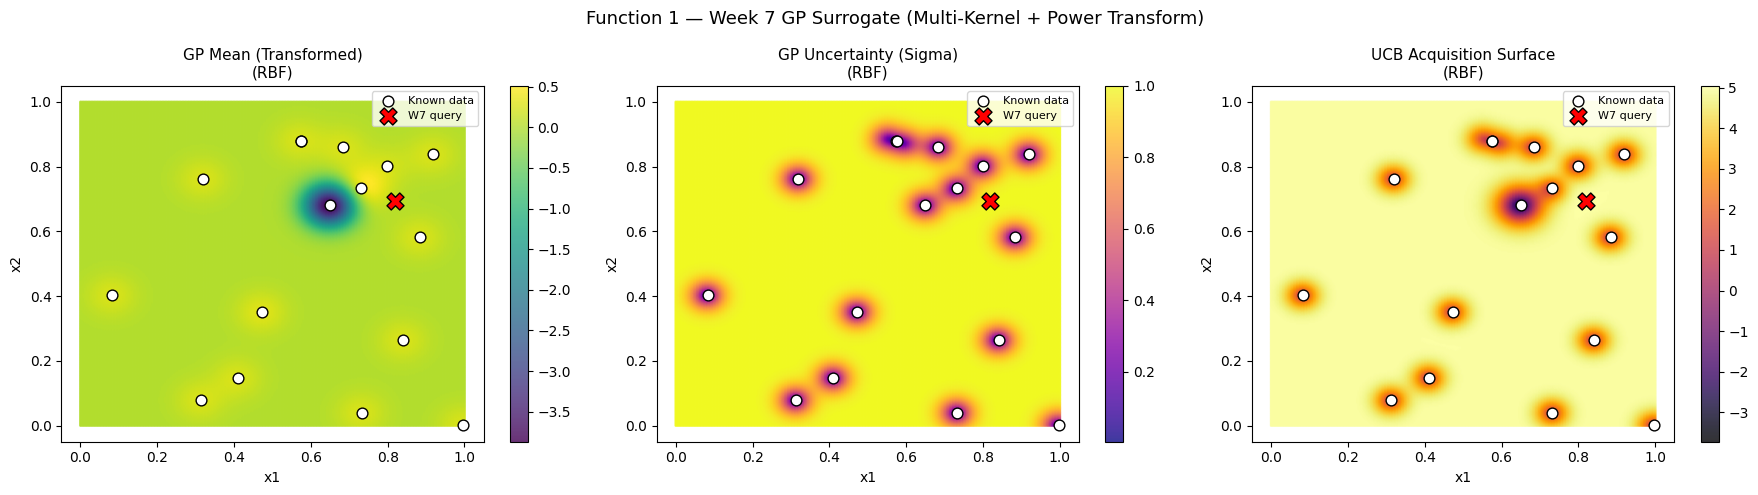

In [6]:
# Refit the winning kernel for plotting
winning_idx   = kernel_names.index(winning_kernel)
winning_model = GaussianProcessRegressor(
    kernel=kernels[winning_idx],
    n_restarts_optimizer=10,
    normalize_y=False
)
winning_model.fit(X_unique, Y_transformed)

mu_grid, sigma_grid = winning_model.predict(x_grid, return_std=True)
ucb_grid            = mu_grid + 5.0 * sigma_grid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles   = ['GP Mean (Transformed)', 'GP Uncertainty (Sigma)', 'UCB Acquisition Surface']
surfaces = [mu_grid, sigma_grid, ucb_grid]
cmaps    = ['viridis', 'plasma', 'inferno']

for ax, surface, title, cmap in zip(axes, surfaces, titles, cmaps):
    sc = ax.scatter(
        x_grid[:, 0], x_grid[:, 1],
        c=surface, cmap=cmap, s=1, alpha=0.8
    )
    # Plot all known data points
    ax.scatter(X_unique[:, 0], X_unique[:, 1],
               c='white', edgecolors='black', s=60, zorder=5, label='Known data')
    
    # Mark the next query
    ax.scatter(next_query[0], next_query[1],
               c='red', edgecolors='black', s=150, zorder=7, marker='X', label='W7 query')
    ax.set_title(f'{title}\n({winning_kernel})', fontsize=11)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    plt.colorbar(sc, ax=ax)
    ax.legend(fontsize=8)

plt.suptitle('Function 1 — Week 7 GP Surrogate (Multi-Kernel + Power Transform)', fontsize=13)
plt.tight_layout()
plt.show()